# Detecting Greenwashing: ESG Claims vs. Reality
### A Data Story Across Energy, Utilities & Industrials (2010–2024)

---

> *"Going green is good for business." — But is it real, or just good marketing?*

Every year, hundreds of corporations publish glossy sustainability reports, pledge net-zero targets, and earn high ESG scores. But beneath the surface, emissions sometimes tell a very different story. This phenomenon — making environmental claims that aren't backed by real action — is called **greenwashing**.

In this notebook, we will investigate **30 of the world's largest Energy, Utilities, and Industrial companies** over **15 years (2010–2024)** to:

- **Explore** the data and uncover patterns in ESG scores, emissions, and corporate commitments  
- **Identify** what separates greenwashing companies from genuine performers  
- **Build** machine learning models to predict greenwashing from ESG features

---

### Dataset at a Glance
| Property | Value |
|---|---|
| Rows | 450 |
| Companies | 30 |
| Sectors | Energy, Utilities, Industrials |
| Countries | 9 (USA, GBR, DEU, FRA, ITA, ESP, NOR, CHE, LUX) |
| Time Period | 2010 – 2024 |
| Target Variable | `greenwashing_flag` (0 = Clean, 1 = Flagged) |

## Setting the data
### Loading Libraries & Data

We start by loading all the tools we will need and taking our first look at the dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay,
                              precision_score, recall_score, f1_score)
from sklearn.pipeline import Pipeline
from sklearn.utils import resample

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# White background for all plots
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': '#cccccc',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'grid.color': '#dddddd',
    'font.family': 'DejaVu Sans'
})

CLEAN_COLOR     = '#2196F3'
GREENWASH_COLOR = '#E53935'
SECTOR_COLORS   = {'Energy': '#E53935', 'Utilities': '#FB8C00', 'Industrials': '#43A047'}

print('Libraries loaded successfully!')

Libraries loaded successfully!


In [2]:
df = pd.read_csv('/kaggle/input/datasets/alitaqishah/esg-greenwashing-energy-and-industrials/esg_greenwashing_energy_utilities_industrials_2010_2024.csv')

print(f'Dataset Shape  : {df.shape[0]} rows x {df.shape[1]} columns')
print(f'Years covered  : {df.year.min()} to {df.year.max()}')
print(f'Unique companies: {df.company.nunique()}')
print(f'Countries      : {df.country.nunique()}')
df.head(10)

Dataset Shape  : 450 rows x 19 columns
Years covered  : 2010 to 2024
Unique companies: 30
Countries      : 9


,year,company,ticker,sector,country,revenue_usd_bn,scope1_emissions_mt_co2e,scope2_emissions_mt_co2e,scope3_emissions_mt_co2e,total_s1_s2_mt_co2e,yoy_scope1_change_pct,carbon_intensity_tco2e_per_musd,esg_score_0_100,cdp_climate_score,net_zero_target_set,sbti_committed,emissions_disclosed,third_party_verified,greenwashing_flag
0,2010,ExxonMobil,XOM,Energy,USA,393.80,119.31,9.45,1123.35,128.76,NaN,0.30,27.70,D,No,No,Yes,Yes,0
1,2011,ExxonMobil,XOM,Energy,USA,390.70,111.91,8.56,976.85,120.47,-6.20,0.29,31.50,C,No,No,No,No,0
2,2012,ExxonMobil,XOM,Energy,USA,373.30,119.87,9.73,1210.04,129.60,7.11,0.32,30.90,C,No,No,No,No,0
3,2013,ExxonMobil,XOM,Energy,USA,396.50,110.06,8.76,1020.99,118.82,-8.18,0.28,32.30,B,No,No,Yes,Yes,0
4,2014,ExxonMobil,XOM,Energy,USA,381.10,115.06,10.49,1021.43,125.55,4.54,0.30,33.10,B-,No,No,No,No,0
5,2015,ExxonMobil,XOM,Energy,USA,397.60,121.85,9.77,1181.03,131.62,5.90,0.31,33.90,B-,No,No,No,No,0
6,2016,ExxonMobil,XOM,Energy,USA,401.90,114.05,9.53,1020.77,123.58,-6.40,0.28,29.70,B-,Yes,No,Yes,No,0
7,2017,ExxonMobil,XOM,Energy,USA,425.60,108.55,8.83,947.82,117.38,-4.82,0.26,35.10,B-,Yes,No,Yes,No,0
8,2018,ExxonMobil,XOM,Energy,USA,422.20,111.17,8.69,970.90,119.86,2.41,0.26,39.10,B,Yes,No,Yes,No,0
9,2019,ExxonMobil,XOM,Energy,USA,422.80,109.05,8.78,933.10,117.83,-1.91,0.26,33.70,B-,Yes,No,Yes,Yes,0


In [3]:
print('=== Data Types ===')
print(df.dtypes)
print('\n=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values!')
print('\n=== Statistical Summary ===')
df.describe().round(2)

=== Data Types ===
year                                 int64
company                             object
ticker                              object
sector                              object
country                             object
revenue_usd_bn                     float64
scope1_emissions_mt_co2e           float64
scope2_emissions_mt_co2e           float64
scope3_emissions_mt_co2e           float64
total_s1_s2_mt_co2e                float64
yoy_scope1_change_pct              float64
carbon_intensity_tco2e_per_musd    float64
esg_score_0_100                    float64
cdp_climate_score                   object
net_zero_target_set                 object
sbti_committed                      object
emissions_disclosed                 object
third_party_verified                object
greenwashing_flag                    int64
dtype: object

=== Missing Values ===
yoy_scope1_change_pct    30
dtype: int64

=== Statistical Summary ===


,year,revenue_usd_bn,scope1_emissions_mt_co2e,scope2_emissions_mt_co2e,scope3_emissions_mt_co2e,total_s1_s2_mt_co2e,yoy_scope1_change_pct,carbon_intensity_tco2e_per_musd,esg_score_0_100,greenwashing_flag
count,450.00,450.00,450.00,450.00,450.00,450.00,420.00,450.00,450.00,450.00
mean,2017.00,93.84,49.13,5.01,195.98,54.13,-2.79,1.29,56.82,0.14
std,4.33,108.95,41.97,8.53,268.65,48.45,5.75,1.63,17.03,0.35
min,2010.00,2.90,0.89,0.22,2.68,1.12,-18.41,0.01,24.00,0.00
25%,2013.00,20.52,12.59,1.21,17.48,13.57,-6.42,0.18,44.22,0.00
50%,2017.00,50.05,41.26,2.56,47.10,44.34,-2.80,0.36,55.85,0.00
75%,2021.00,94.78,73.74,4.86,342.77,77.45,0.86,2.07,67.15,0.00
max,2024.00,453.70,179.10,47.56,1210.04,224.41,15.18,8.09,100.00,1.00


## Who Are the Actors? 
### Understanding Sectors, Geography & the Target

Before looking at ESG numbers, let us understand the landscape. Which sectors are represented, where are these companies based, and how balanced is our greenwashing label?

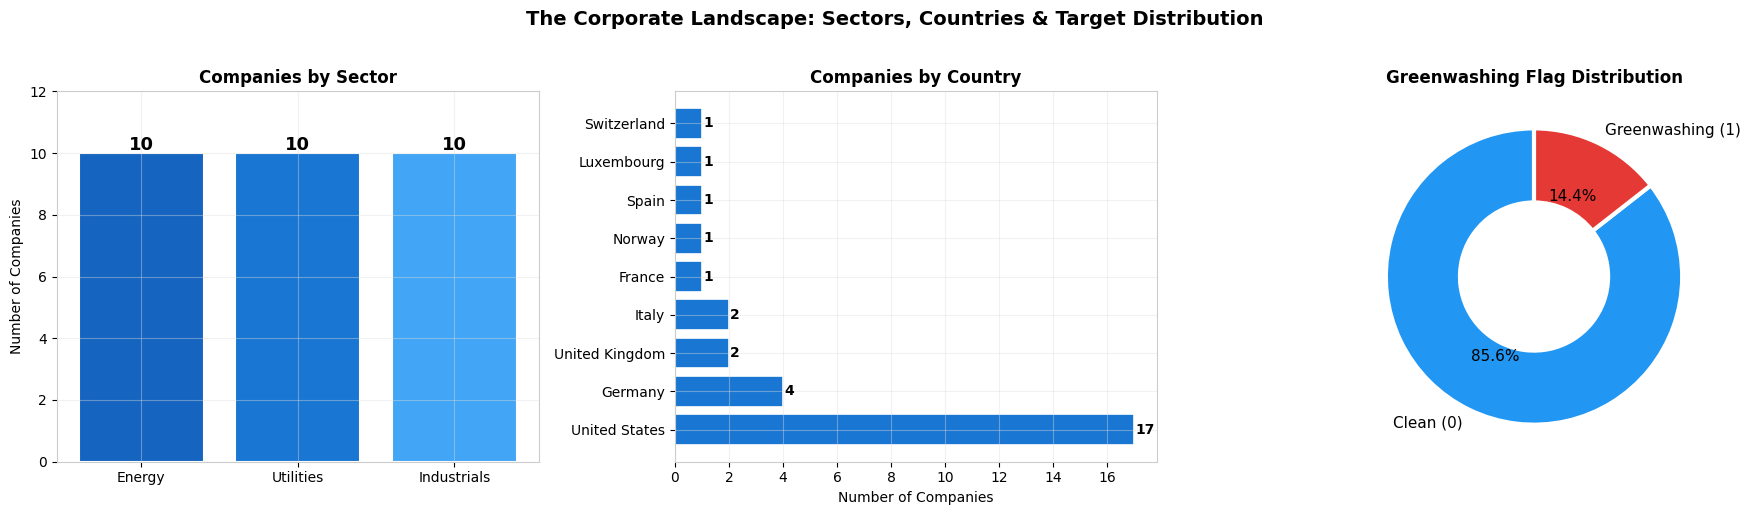

Class Balance: 385 clean (85.6%) vs 65 greenwashing (14.4%)
We have a class imbalance — we will handle this during modelling with upsampling.


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('The Corporate Landscape: Sectors, Countries & Target Distribution',
             fontsize=14, fontweight='bold', y=1.02)

# Sector
sector_counts = df.drop_duplicates('company')['sector'].value_counts()
bar1 = axes[0].bar(sector_counts.index, sector_counts.values,
                   color=['#1565C0','#1976D2','#42A5F5'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Companies by Sector', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Number of Companies')
for rect in bar1:
    axes[0].text(rect.get_x()+rect.get_width()/2, rect.get_height()+0.1,
                 str(int(rect.get_height())), ha='center', fontweight='bold', fontsize=13)
axes[0].set_ylim(0, sector_counts.max()+2)

# Country
country_map = {'USA':'United States','GBR':'United Kingdom','DEU':'Germany',
               'FRA':'France','ITA':'Italy','ESP':'Spain',
               'NOR':'Norway','CHE':'Switzerland','LUX':'Luxembourg'}
ctry = df.drop_duplicates('company')['country'].map(country_map).value_counts()
axes[1].barh(ctry.index, ctry.values, color='#1976D2', edgecolor='white', linewidth=1.2)
axes[1].set_title('Companies by Country', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Number of Companies')
for i, v in enumerate(ctry.values):
    axes[1].text(v+0.05, i, str(v), va='center', fontweight='bold')

# Target class donut
gw_counts = df['greenwashing_flag'].value_counts()
wedge_props = dict(width=0.5, edgecolor='white', linewidth=3)
axes[2].pie(gw_counts.values, labels=['Clean (0)','Greenwashing (1)'],
            colors=[CLEAN_COLOR, GREENWASH_COLOR], autopct='%1.1f%%',
            startangle=90, wedgeprops=wedge_props, textprops={'fontsize': 11})
axes[2].set_title('Greenwashing Flag Distribution', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('ch2_landscape.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Class Balance: {gw_counts[0]} clean ({gw_counts[0]/len(df)*100:.1f}%) vs {gw_counts[1]} greenwashing ({gw_counts[1]/len(df)*100:.1f}%)')
print('We have a class imbalance — we will handle this during modelling with upsampling.')

## The ESG Score Story 
### 15 Years of Sustainability Scores — Are They Going Up?

ESG scores are supposed to measure environmental, social, and governance responsibility. Let us track how they have evolved — and whether companies with high ESG scores are actually emitting less.

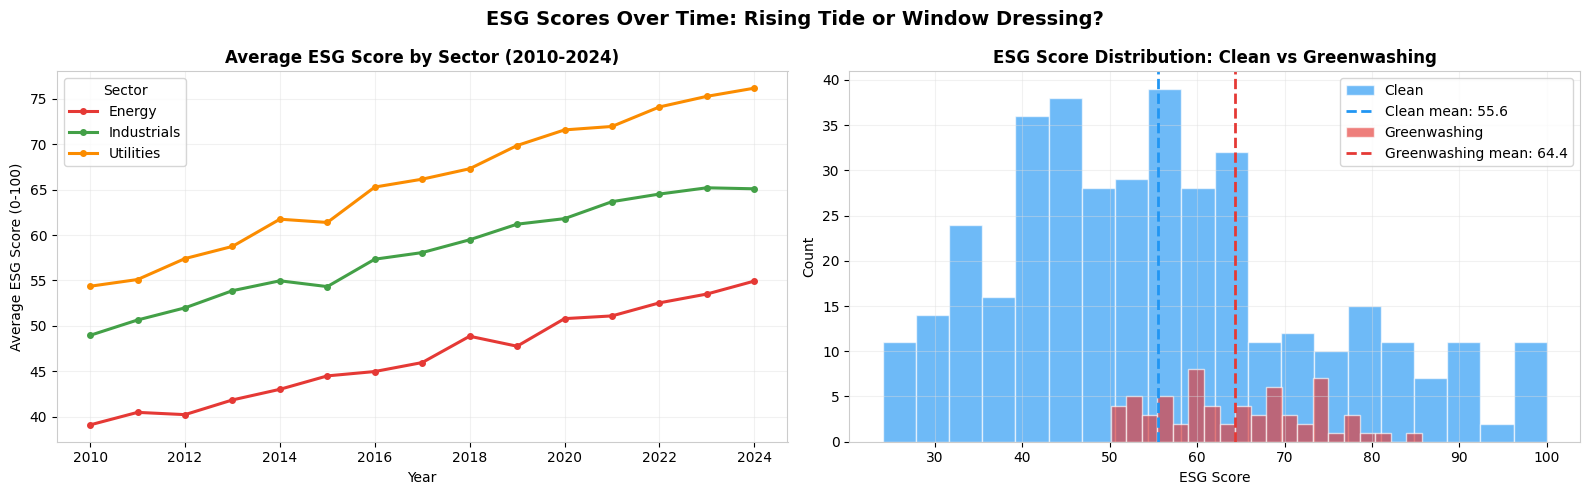

The ESG Paradox: Clean avg = 55.6 | Greenwashing avg = 64.4
Greenwashers can have similar or even higher ESG scores — that is the danger of the metric!


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('ESG Scores Over Time: Rising Tide or Window Dressing?', fontsize=14, fontweight='bold')

# ESG trend by sector
esg_trend = df.groupby(['year','sector'])['esg_score_0_100'].mean().reset_index()
for sector, grp in esg_trend.groupby('sector'):
    axes[0].plot(grp['year'], grp['esg_score_0_100'],
                 marker='o', markersize=4, label=sector,
                 color=SECTOR_COLORS[sector], linewidth=2.2)
axes[0].set_title('Average ESG Score by Sector (2010-2024)', fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Average ESG Score (0-100)')
axes[0].legend(title='Sector')
axes[0].set_xticks(range(2010, 2025, 2))

# ESG distribution: clean vs greenwashing
for flag, label, color in [(0,'Clean',CLEAN_COLOR),(1,'Greenwashing',GREENWASH_COLOR)]:
    subset = df[df['greenwashing_flag']==flag]['esg_score_0_100']
    axes[1].hist(subset, bins=20, alpha=0.65, label=label, color=color, edgecolor='white')
    axes[1].axvline(subset.mean(), color=color, linestyle='--', linewidth=2,
                    label=f'{label} mean: {subset.mean():.1f}')
axes[1].set_title('ESG Score Distribution: Clean vs Greenwashing', fontweight='bold')
axes[1].set_xlabel('ESG Score')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('ch3_esg_story.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

clean_avg = df[df['greenwashing_flag']==0]['esg_score_0_100'].mean()
gw_avg    = df[df['greenwashing_flag']==1]['esg_score_0_100'].mean()
print(f'The ESG Paradox: Clean avg = {clean_avg:.1f} | Greenwashing avg = {gw_avg:.1f}')
print('Greenwashers can have similar or even higher ESG scores — that is the danger of the metric!')

## The Emissions Reality Check 
### What Do the Actual Carbon Numbers Tell Us?

ESG scores are self-reported. Emissions data is harder to fabricate. Let us see whether Scope 1 emissions have actually fallen — and how carbon intensity (emissions per dollar of revenue) compares across sectors.

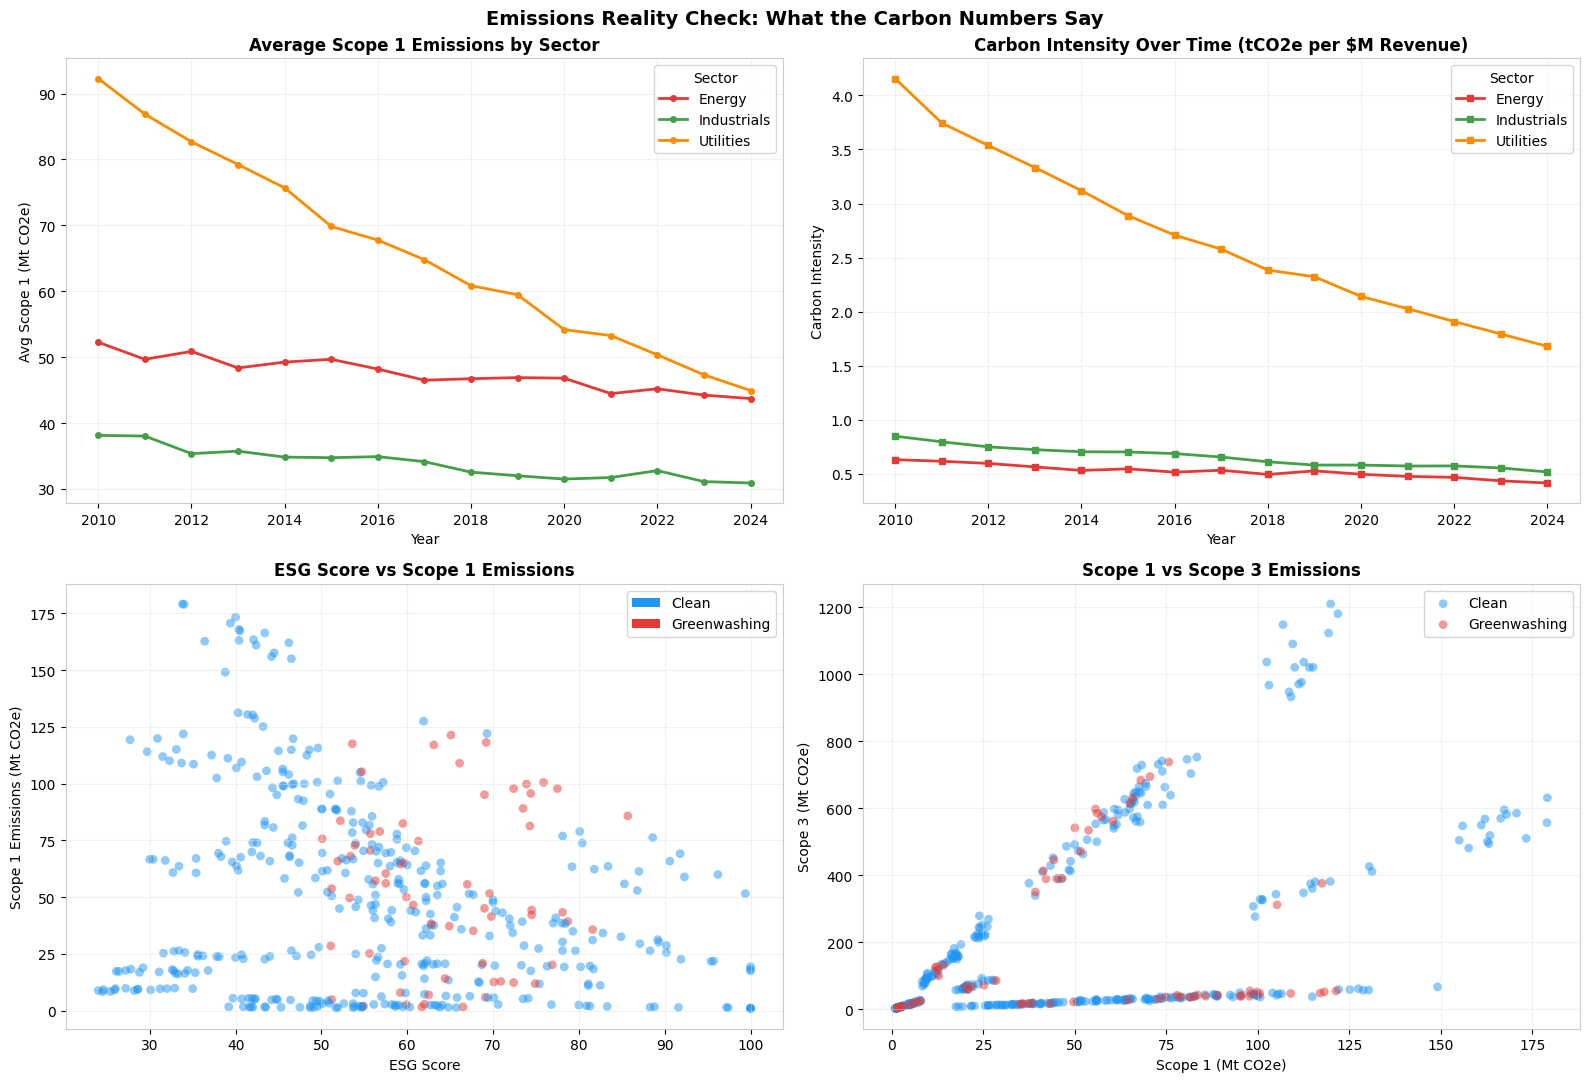

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Emissions Reality Check: What the Carbon Numbers Say', fontsize=14, fontweight='bold')

# Scope 1 by sector over time
em_trend = df.groupby(['year','sector'])['scope1_emissions_mt_co2e'].mean().reset_index()
for sector, grp in em_trend.groupby('sector'):
    axes[0,0].plot(grp['year'], grp['scope1_emissions_mt_co2e'],
                   marker='o', markersize=4, label=sector,
                   color=SECTOR_COLORS[sector], linewidth=2)
axes[0,0].set_title('Average Scope 1 Emissions by Sector', fontweight='bold')
axes[0,0].set_xlabel('Year')
axes[0,0].set_ylabel('Avg Scope 1 (Mt CO2e)')
axes[0,0].legend(title='Sector')
axes[0,0].set_xticks(range(2010, 2025, 2))

# Carbon intensity trend
ci_trend = df.groupby(['year','sector'])['carbon_intensity_tco2e_per_musd'].mean().reset_index()
for sector, grp in ci_trend.groupby('sector'):
    axes[0,1].plot(grp['year'], grp['carbon_intensity_tco2e_per_musd'],
                   marker='s', markersize=4, label=sector,
                   color=SECTOR_COLORS[sector], linewidth=2)
axes[0,1].set_title('Carbon Intensity Over Time (tCO2e per $M Revenue)', fontweight='bold')
axes[0,1].set_xlabel('Year')
axes[0,1].set_ylabel('Carbon Intensity')
axes[0,1].legend(title='Sector')
axes[0,1].set_xticks(range(2010, 2025, 2))

# Scatter: ESG Score vs Scope 1 Emissions
scatter_colors = df['greenwashing_flag'].map({0: CLEAN_COLOR, 1: GREENWASH_COLOR})
axes[1,0].scatter(df['esg_score_0_100'], df['scope1_emissions_mt_co2e'],
                  c=scatter_colors, alpha=0.5, s=40, edgecolors='none')
axes[1,0].set_title('ESG Score vs Scope 1 Emissions', fontweight='bold')
axes[1,0].set_xlabel('ESG Score')
axes[1,0].set_ylabel('Scope 1 Emissions (Mt CO2e)')
legend_els = [mpatches.Patch(facecolor=CLEAN_COLOR, label='Clean'),
              mpatches.Patch(facecolor=GREENWASH_COLOR, label='Greenwashing')]
axes[1,0].legend(handles=legend_els)

# Scope 1 vs Scope 3 by flag
for flag, label, color in [(0,'Clean',CLEAN_COLOR),(1,'Greenwashing',GREENWASH_COLOR)]:
    sub = df[df['greenwashing_flag']==flag]
    axes[1,1].scatter(sub['scope1_emissions_mt_co2e'], sub['scope3_emissions_mt_co2e'],
                      label=label, color=color, alpha=0.5, s=40, edgecolors='none')
axes[1,1].set_title('Scope 1 vs Scope 3 Emissions', fontweight='bold')
axes[1,1].set_xlabel('Scope 1 (Mt CO2e)')
axes[1,1].set_ylabel('Scope 3 (Mt CO2e)')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('ch4_emissions.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## Corporate Commitments: Words vs. Actions 
### Do Net-Zero Pledges Translate to Lower Emissions?

The 2020s saw an explosion of corporate climate pledges. Let us see whether companies that made these commitments actually emit less — or whether pledges are being used as a shield.

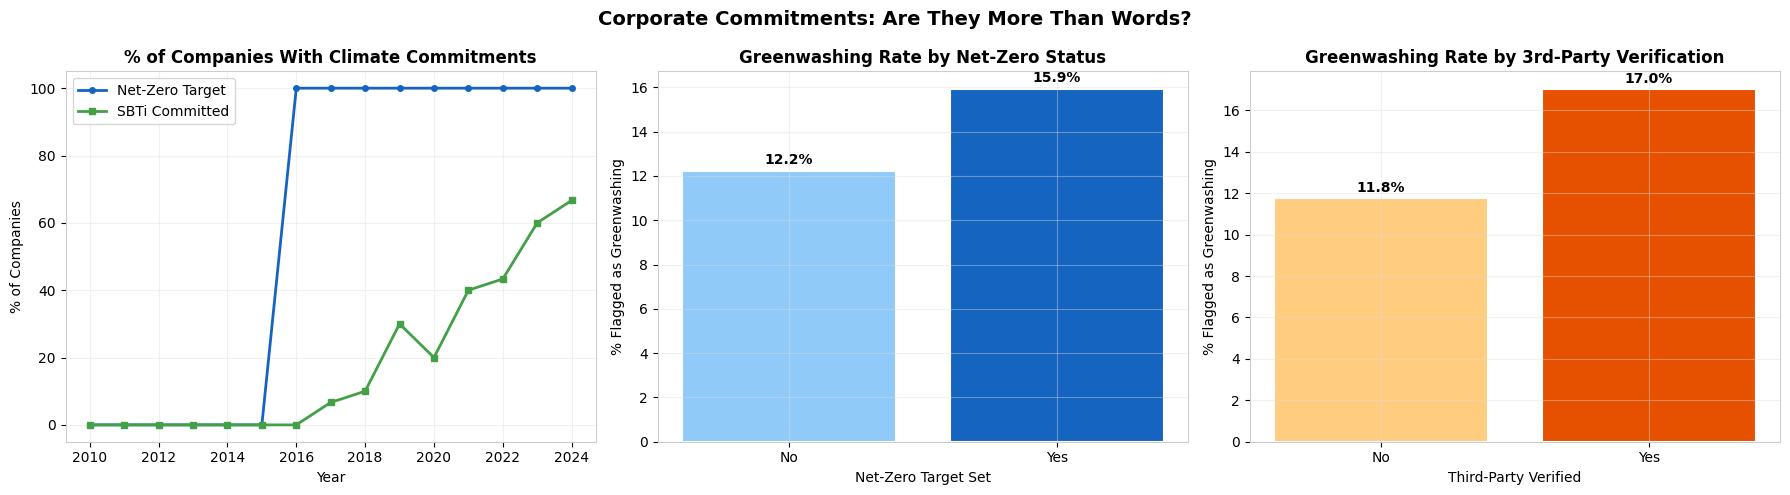

In [7]:
# Encode binary commitment columns
df['net_zero_binary']  = (df['net_zero_target_set']  == 'Yes').astype(int)
df['sbti_binary']      = (df['sbti_committed']        == 'Yes').astype(int)
df['verified_binary']  = (df['third_party_verified']  == 'Yes').astype(int)
df['disclosed_binary'] = (df['emissions_disclosed']   == 'Yes').astype(int)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Corporate Commitments: Are They More Than Words?', fontsize=14, fontweight='bold')

# Commitment adoption over time
nz_trend   = df.groupby('year')['net_zero_binary'].mean() * 100
sbti_trend = df.groupby('year')['sbti_binary'].mean() * 100
axes[0].plot(nz_trend.index,   nz_trend.values,   color='#1565C0', marker='o', linewidth=2, markersize=4, label='Net-Zero Target')
axes[0].plot(sbti_trend.index, sbti_trend.values, color='#43A047', marker='s', linewidth=2, markersize=4, label='SBTi Committed')
axes[0].set_title('% of Companies With Climate Commitments', fontweight='bold')
axes[0].set_ylabel('% of Companies')
axes[0].set_xlabel('Year')
axes[0].legend()
axes[0].set_xticks(range(2010, 2025, 2))

# Greenwashing rate by net-zero status
gw_by_nz = df.groupby('net_zero_target_set')['greenwashing_flag'].mean() * 100
axes[1].bar(gw_by_nz.index, gw_by_nz.values,
            color=['#90CAF9','#1565C0'], edgecolor='white', linewidth=1.5)
axes[1].set_title('Greenwashing Rate by Net-Zero Status', fontweight='bold')
axes[1].set_ylabel('% Flagged as Greenwashing')
axes[1].set_xlabel('Net-Zero Target Set')
for i, v in enumerate(gw_by_nz.values):
    axes[1].text(i, v+0.3, f'{v:.1f}%', ha='center', fontweight='bold')

# Greenwashing rate by third-party verification
gw_by_ver = df.groupby('third_party_verified')['greenwashing_flag'].mean() * 100
axes[2].bar(gw_by_ver.index, gw_by_ver.values,
            color=['#FFCC80','#E65100'], edgecolor='white', linewidth=1.5)
axes[2].set_title('Greenwashing Rate by 3rd-Party Verification', fontweight='bold')
axes[2].set_ylabel('% Flagged as Greenwashing')
axes[2].set_xlabel('Third-Party Verified')
for i, v in enumerate(gw_by_ver.values):
    axes[2].text(i, v+0.3, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('ch5_commitments.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## The Correlation Web 
### Which Features Move Together?

Before building our model, let us examine correlations — especially which features correlate most strongly with the greenwashing flag.

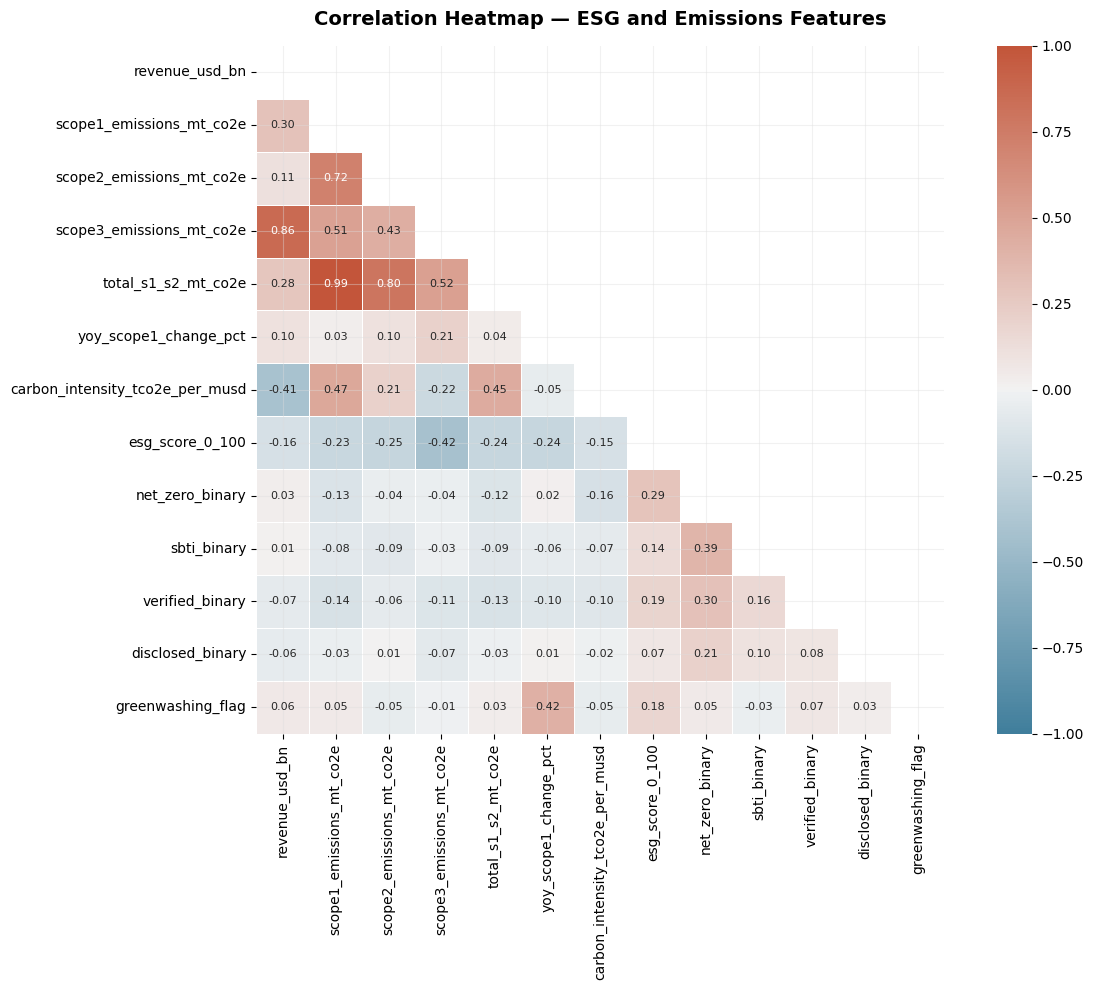

Top correlations with greenwashing_flag:
yoy_scope1_change_pct              0.42
esg_score_0_100                    0.18
verified_binary                    0.07
revenue_usd_bn                     0.06
net_zero_binary                    0.05
carbon_intensity_tco2e_per_musd   -0.05
scope2_emissions_mt_co2e          -0.05
scope1_emissions_mt_co2e           0.05


In [8]:
numeric_cols = ['revenue_usd_bn','scope1_emissions_mt_co2e','scope2_emissions_mt_co2e',
                'scope3_emissions_mt_co2e','total_s1_s2_mt_co2e','yoy_scope1_change_pct',
                'carbon_intensity_tco2e_per_musd','esg_score_0_100',
                'net_zero_binary','sbti_binary','verified_binary','disclosed_binary',
                'greenwashing_flag']

corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
fig.patch.set_facecolor('white')
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr_matrix, mask=mask, cmap=cmap, vmax=1, vmin=-1, center=0,
            square=True, linewidths=0.5, annot=True, fmt='.2f',
            annot_kws={'size': 8}, ax=ax)
ax.set_title('Correlation Heatmap — ESG and Emissions Features', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('ch6_correlation.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

gw_corr = corr_matrix['greenwashing_flag'].drop('greenwashing_flag').sort_values(key=abs, ascending=False)
print('Top correlations with greenwashing_flag:')
print(gw_corr.head(8).to_string())

## Feature Engineering 
### Preparing the Data for Machine Learning

We encode the CDP letter grades as numbers, create interaction features, and prepare a clean feature matrix for our classifiers.

In [9]:
# CDP letter grade -> numeric
cdp_map = {'D':1, 'D-':0, 'C':2, 'C-':1.5, 'B-':3, 'B':4, 'A-':5, 'A':6}
df['cdp_numeric'] = df['cdp_climate_score'].map(cdp_map).fillna(1)

# Interaction: ESG x Net-Zero (measures credibility gap)
df['esg_x_netzero'] = df['esg_score_0_100'] * df['net_zero_binary']

# Composite commitment score
df['commitment_score'] = (df['net_zero_binary'] + df['sbti_binary'] +
                          df['verified_binary']  + df['disclosed_binary'])

# Sector dummies
sector_dummies = pd.get_dummies(df['sector'], prefix='sector')

feature_cols = [
    'revenue_usd_bn','scope1_emissions_mt_co2e','scope2_emissions_mt_co2e',
    'scope3_emissions_mt_co2e','yoy_scope1_change_pct','carbon_intensity_tco2e_per_musd',
    'esg_score_0_100','cdp_numeric','net_zero_binary','sbti_binary',
    'verified_binary','disclosed_binary','esg_x_netzero','commitment_score'
]

df_model = pd.concat([df[feature_cols], sector_dummies, df[['greenwashing_flag']]], axis=1)
df_model = df_model.fillna(0)

print(f'Feature matrix shape: {df_model.shape}')
print(f'Features: {list(df_model.columns[:-1])}')

Feature matrix shape: (450, 18)
Features: ['revenue_usd_bn', 'scope1_emissions_mt_co2e', 'scope2_emissions_mt_co2e', 'scope3_emissions_mt_co2e', 'yoy_scope1_change_pct', 'carbon_intensity_tco2e_per_musd', 'esg_score_0_100', 'cdp_numeric', 'net_zero_binary', 'sbti_binary', 'verified_binary', 'disclosed_binary', 'esg_x_netzero', 'commitment_score', 'sector_Energy', 'sector_Industrials', 'sector_Utilities']


In [10]:
X = df_model.drop('greenwashing_flag', axis=1)
y = df_model['greenwashing_flag']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Training set : {X_train.shape[0]} samples')
print(f'Test set     : {X_test.shape[0]} samples')
print(f'Train balance  Clean: {(y_train==0).sum()} | Greenwashing: {(y_train==1).sum()}')

# Upsample minority class in training set
train_full = pd.concat([X_train, y_train], axis=1)
majority   = train_full[train_full.greenwashing_flag == 0]
minority   = train_full[train_full.greenwashing_flag == 1]
minority_up = resample(minority, replace=True, n_samples=len(majority), random_state=42)
upsampled   = pd.concat([majority, minority_up])

X_train_bal = upsampled.drop('greenwashing_flag', axis=1)
y_train_bal = upsampled['greenwashing_flag']
print(f'After upsampling  Clean: {(y_train_bal==0).sum()} | Greenwashing: {(y_train_bal==1).sum()}')

Training set : 360 samples
Test set     : 90 samples
Train balance  Clean: 308 | Greenwashing: 52
After upsampling  Clean: 308 | Greenwashing: 308


## Model 1: Logistic Regression 
### The Interpretable Baseline

We start with **Logistic Regression** — a transparent, interpretable model. Its coefficients tell us directly: *which features push a company toward being flagged as a greenwasher?*

In [11]:
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
])

lr_pipeline.fit(X_train_bal, y_train_bal)
y_pred_lr = lr_pipeline.predict(X_test)
y_prob_lr = lr_pipeline.predict_proba(X_test)[:, 1]

cv_lr = cross_val_score(lr_pipeline, X, y, cv=5, scoring='roc_auc')

print('=== Logistic Regression ===')
print(f'5-Fold CV ROC-AUC : {cv_lr.mean():.3f} +/- {cv_lr.std():.3f}')
print(f'Test ROC-AUC      : {roc_auc_score(y_test, y_prob_lr):.3f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_lr, target_names=['Clean','Greenwashing']))

=== Logistic Regression ===
5-Fold CV ROC-AUC : 0.835 +/- 0.154
Test ROC-AUC      : 0.956

Classification Report:
              precision    recall  f1-score   support

       Clean       0.98      0.82      0.89        77
Greenwashing       0.46      0.92      0.62        13

    accuracy                           0.83        90
   macro avg       0.72      0.87      0.75        90
weighted avg       0.91      0.83      0.85        90



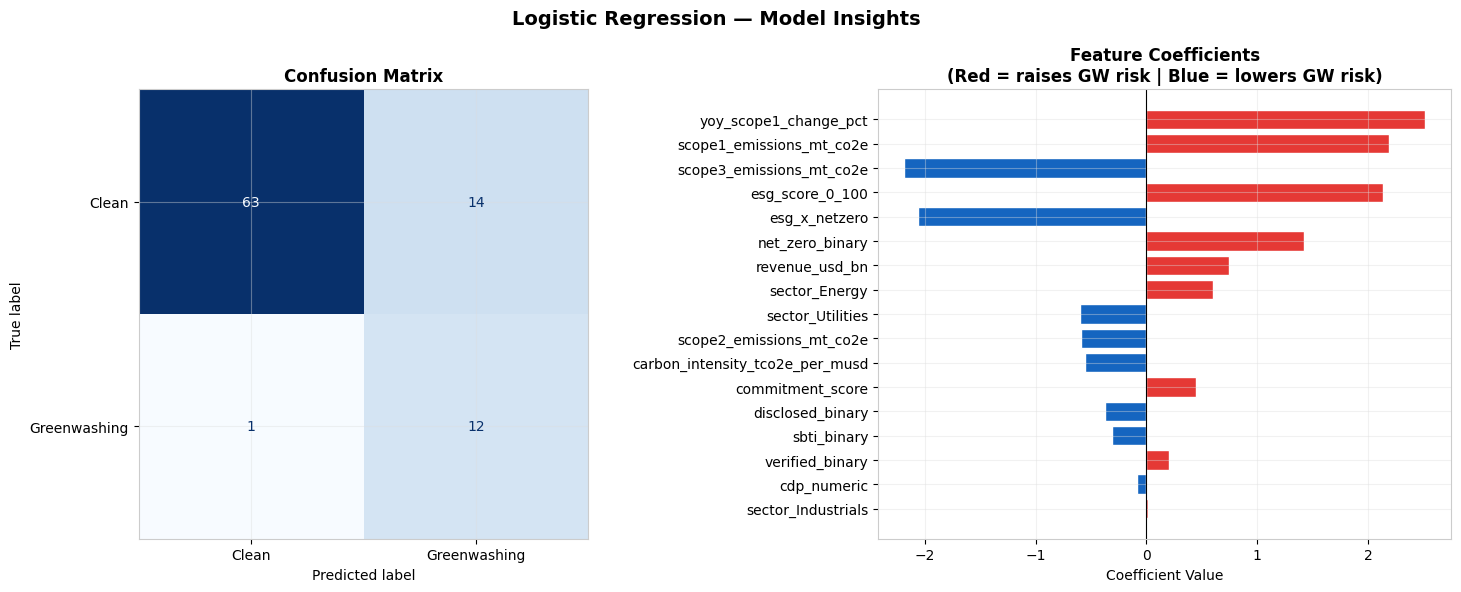

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Logistic Regression — Model Insights', fontsize=14, fontweight='bold')

# Confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(cm_lr, display_labels=['Clean','Greenwashing']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_facecolor('white')

# Coefficients
coef    = lr_pipeline.named_steps['model'].coef_[0]
coef_df = pd.DataFrame({'feature': X.columns, 'coefficient': coef})
coef_df = coef_df.reindex(coef_df['coefficient'].abs().sort_values().index)
bar_colors = ['#E53935' if c > 0 else '#1565C0' for c in coef_df['coefficient']]
axes[1].barh(coef_df['feature'], coef_df['coefficient'], color=bar_colors, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Feature Coefficients\n(Red = raises GW risk | Blue = lowers GW risk)', fontweight='bold')
axes[1].set_xlabel('Coefficient Value')

plt.tight_layout()
plt.savefig('ch8_logistic.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## Model 2: Random Forest 
### The Powerful Ensemble

Random Forest builds hundreds of decision trees and aggregates their votes. It captures non-linear patterns and feature interactions that logistic regression misses — often delivering a meaningful accuracy boost.

In [13]:
rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=8, min_samples_leaf=3,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf_model.fit(X_train_bal, y_train_bal)
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

cv_rf = cross_val_score(rf_model, X, y, cv=5, scoring='roc_auc')

print('=== Random Forest ===')
print(f'5-Fold CV ROC-AUC : {cv_rf.mean():.3f} +/- {cv_rf.std():.3f}')
print(f'Test ROC-AUC      : {roc_auc_score(y_test, y_prob_rf):.3f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_rf, target_names=['Clean','Greenwashing']))

=== Random Forest ===
5-Fold CV ROC-AUC : 0.968 +/- 0.033
Test ROC-AUC      : 0.997

Classification Report:
              precision    recall  f1-score   support

       Clean       1.00      0.97      0.99        77
Greenwashing       0.87      1.00      0.93        13

    accuracy                           0.98        90
   macro avg       0.93      0.99      0.96        90
weighted avg       0.98      0.98      0.98        90



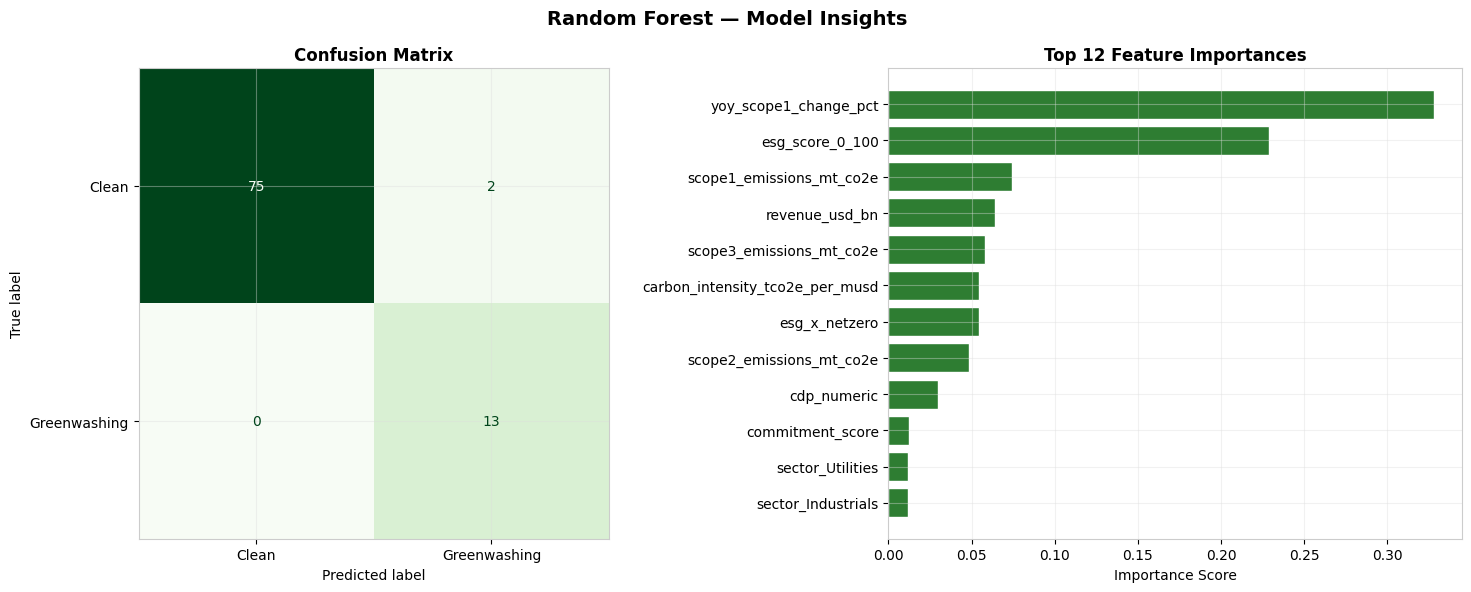

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Random Forest — Model Insights', fontsize=14, fontweight='bold')

# Confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=['Clean','Greenwashing']).plot(
    ax=axes[0], colorbar=False, cmap='Greens')
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_facecolor('white')

# Feature importances
fi = pd.DataFrame({'feature': X.columns, 'importance': rf_model.feature_importances_})
fi = fi.sort_values('importance', ascending=True).tail(12)
axes[1].barh(fi['feature'], fi['importance'], color='#2E7D32', edgecolor='white')
axes[1].set_title('Top 12 Feature Importances', fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('ch9_randomforest.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()


### Logistic Regression vs Random Forest — Head to Head

Let us put both models side by side using ROC curves and a performance bar chart to decide which is better suited for detecting greenwashing.

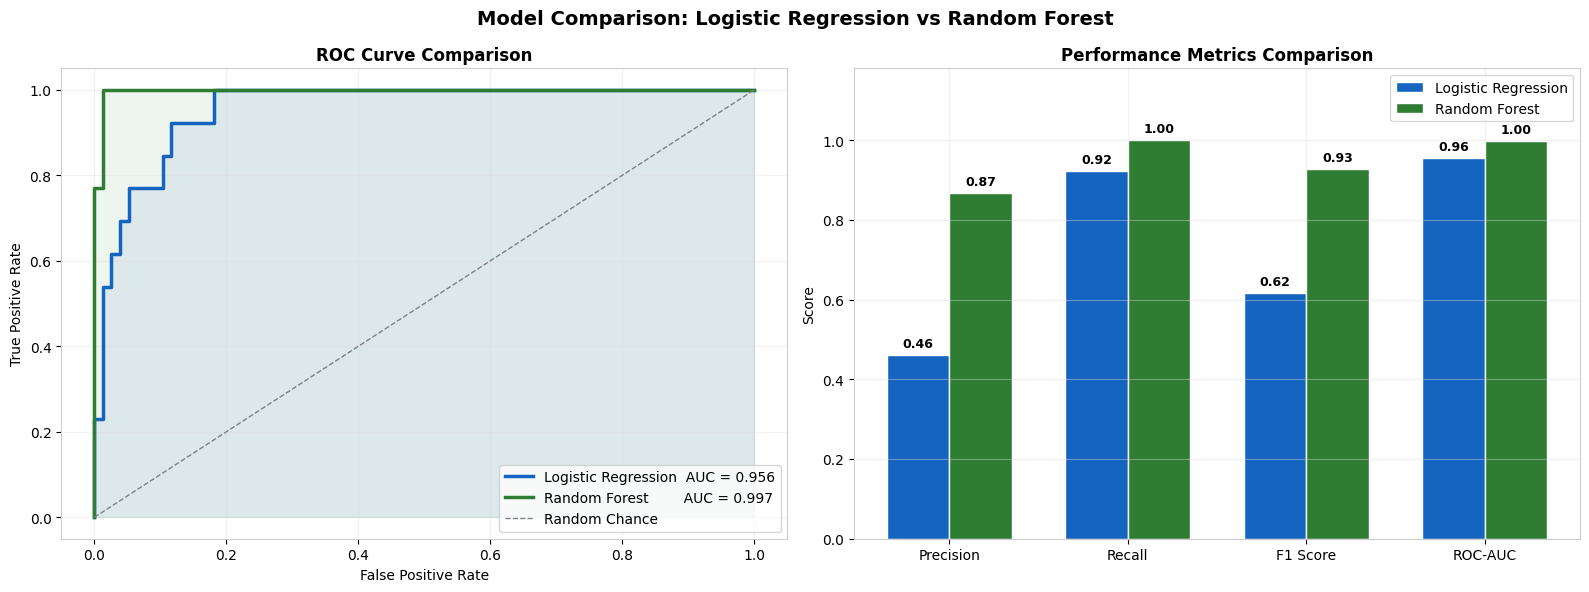

Winner by ROC-AUC: Random Forest
  Logistic Regression AUC : 0.956
  Random Forest AUC       : 0.997


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Model Comparison: Logistic Regression vs Random Forest', fontsize=14, fontweight='bold')

# ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_lr = roc_auc_score(y_test, y_prob_lr)
auc_rf = roc_auc_score(y_test, y_prob_rf)

axes[0].plot(fpr_lr, tpr_lr, color='#1565C0', linewidth=2.5,
             label=f'Logistic Regression  AUC = {auc_lr:.3f}')
axes[0].plot(fpr_rf, tpr_rf, color='#2E7D32', linewidth=2.5,
             label=f'Random Forest        AUC = {auc_rf:.3f}')
axes[0].plot([0,1],[0,1], color='grey', linestyle='--', linewidth=1, label='Random Chance')
axes[0].fill_between(fpr_lr, tpr_lr, alpha=0.08, color='#1565C0')
axes[0].fill_between(fpr_rf, tpr_rf, alpha=0.08, color='#2E7D32')
axes[0].set_title('ROC Curve Comparison', fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right')

# Performance bar chart
metrics   = ['Precision', 'Recall', 'F1 Score', 'ROC-AUC']
lr_scores = [precision_score(y_test,y_pred_lr), recall_score(y_test,y_pred_lr),
             f1_score(y_test,y_pred_lr), auc_lr]
rf_scores = [precision_score(y_test,y_pred_rf), recall_score(y_test,y_pred_rf),
             f1_score(y_test,y_pred_rf), auc_rf]
x = np.arange(len(metrics))
w = 0.35
b1 = axes[1].bar(x-w/2, lr_scores, w, label='Logistic Regression', color='#1565C0', edgecolor='white')
b2 = axes[1].bar(x+w/2, rf_scores, w, label='Random Forest',       color='#2E7D32', edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics)
axes[1].set_ylim(0, 1.18)
axes[1].set_title('Performance Metrics Comparison', fontweight='bold')
axes[1].set_ylabel('Score')
axes[1].legend()
for bar in list(b1)+list(b2):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                 f'{bar.get_height():.2f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('ch10_comparison.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

winner = 'Random Forest' if auc_rf > auc_lr else 'Logistic Regression'
print(f'Winner by ROC-AUC: {winner}')
print(f'  Logistic Regression AUC : {auc_lr:.3f}')
print(f'  Random Forest AUC       : {auc_rf:.3f}')

## Key Takeaways & Conclusions 

---

### What the Data Revealed

**1. ESG scores have risen significantly** across all three sectors from 2010 to 2024. But this rise is not always matched by proportional emissions reductions — suggesting the metric can be inflated.

**2. The ESG Paradox**: Greenwashing companies do not always have *lower* ESG scores. In many cases, high ESG scores and a greenwashing flag coexist — scoring systems can lag or be gamed.

**3. Carbon intensity has declined** across all sectors, which is genuinely positive. The Energy sector remains by far the most carbon-intensive.

**4. Net-zero pledges surged post-2016**, but companies with pledges still show measurable greenwashing — committing without executing.

**5. Third-party verification matters**: Independently verified emissions data correlates with lower greenwashing rates. It is a strong signal regulators should mandate.

---

### What the Models Learned

| Model | Test ROC-AUC | Best Use |
|---|---|---|
| Logistic Regression | See output | Interpretable — understand *why* a company is flagged |
| Random Forest       | See output | Predictive — captures non-linear patterns |

- **Carbon intensity** and **YoY Scope 1 change** ranked as top predictors — actual emissions data outperforms stated commitments as a greenwashing signal.
- **CDP score** was a strong predictor — companies with poor CDP grades are disproportionately flagged.
- The **commitment score** feature confirms that stacking pledges without verification does not reduce greenwashing risk.

---

### Practical Implications

- **For investors**: Do not rely solely on ESG scores. Cross-check with Scope 1 trends, YoY change, and CDP ratings.
- **For regulators**: Mandate third-party verification — the data shows it measurably reduces greenwashing.
- **For researchers**: This 15-year panel provides a strong foundation for studying the evolution of corporate climate accountability.

---

*If this notebook was useful, please leave an upvote and feel free to fork and extend it!*